In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from src.data_prep.pre_process import get_features_df
from src.models.Features_Models_Selection import feature_selection, model_selection
from src.models.models_functions import model, scale
from src.models.Parameters_Tuning.best_param_to_xl import get_best_param_optuna


shap.initjs()

In [3]:
RNA_TYPE = 'p'

data = get_features_df(rna_type=RNA_TYPE)

RNA_X_train_features = data[f'RNA{RNA_TYPE}_X_train']
RNA_X_train_seq = data[f'RNA{RNA_TYPE}_X_train_sequences']
RNA_y_train = data[f'RNA{RNA_TYPE}_y_train']

RNA_X_val_features = data[f'RNA{RNA_TYPE}_X_val']
RNA_X_val_seq = data[f'RNA{RNA_TYPE}_X_val_sequences']
RNA_y_val = data[f'RNA{RNA_TYPE}_y_val']

RNA_X_test_features = data[f'RNA{RNA_TYPE}_X_test']
RNA_y_test = data[f'RNA{RNA_TYPE}_y_test']



In [4]:
param_dict = model_selection(RNA_X_train_features, RNA_X_val_features, RNA_y_train, RNA_y_val, RNA_TYPE)
cur_model_name = 'CatBoostRegressor'

In [5]:
RNA_selected_features = feature_selection(RNA_X_train_features, RNA_y_train, param_dict, cur_model_name, RNA_TYPE)

RNA_FS_train = RNA_X_train_features[RNA_selected_features]
RNA_FS_val = RNA_X_val_features[RNA_selected_features]
RNA_FS_test = RNA_X_test_features[RNA_selected_features]

# Hyperparameters tuning
Best_params = get_best_param_optuna(RNA_FS_train, RNA_FS_val, RNA_y_train, RNA_y_val, cur_model_name, RNA_TYPE)

# Run model
RNA_FS_train_val_X = pd.concat([RNA_FS_train, RNA_FS_val])
RNA_train_val_seq = pd.concat([RNA_X_train_seq, RNA_X_val_seq])
RNA_train_val_y = pd.concat([RNA_y_train, RNA_y_val])
trained_model, _, _, _, _, _ = model(RNA_FS_train_val_X, RNA_FS_test,
                                                    RNA_train_val_y, RNA_y_test,
                                                    cur_model_name, f'RNA{RNA_TYPE}', Best_params,
                                                    save_plots=False, do_scale=False)

Running CatBoostRegressor for RNAp with 18 features
R^2 value for CatBoostRegressor: 0.8990229776718677
MAE value for CatBoostRegressor: 22.110365576785224
pearson correlation value for CatBoostRegressor: 0.9500219179176107, p-value = 1.52e-64
spearman correlation value for CatBoostRegressor: 0.8538406737448464, p-value = 5.77e-37


In [6]:
RNA_FS_X = pd.concat([RNA_FS_train_val_X, RNA_FS_test])
RNA_y = pd.concat([RNA_train_val_y, RNA_y_test])

y_pred = trained_model.predict(RNA_FS_X)
explainer = shap.Explainer(trained_model)
shap_values = explainer(RNA_FS_X)

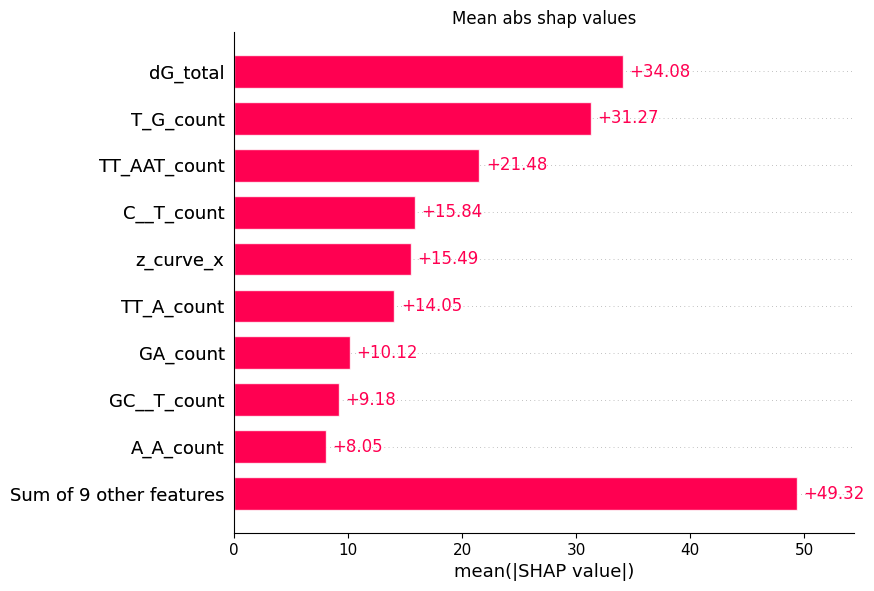

In [7]:
plot = shap.force_plot(explainer.expected_value, shap_values.values, RNA_FS_X, show=False)
shap.save_html(f"shap_force_plot_RNA{RNA_TYPE}.html", plot)
plt.title('Mean abs shap values')
shap.plots.bar(shap_values)

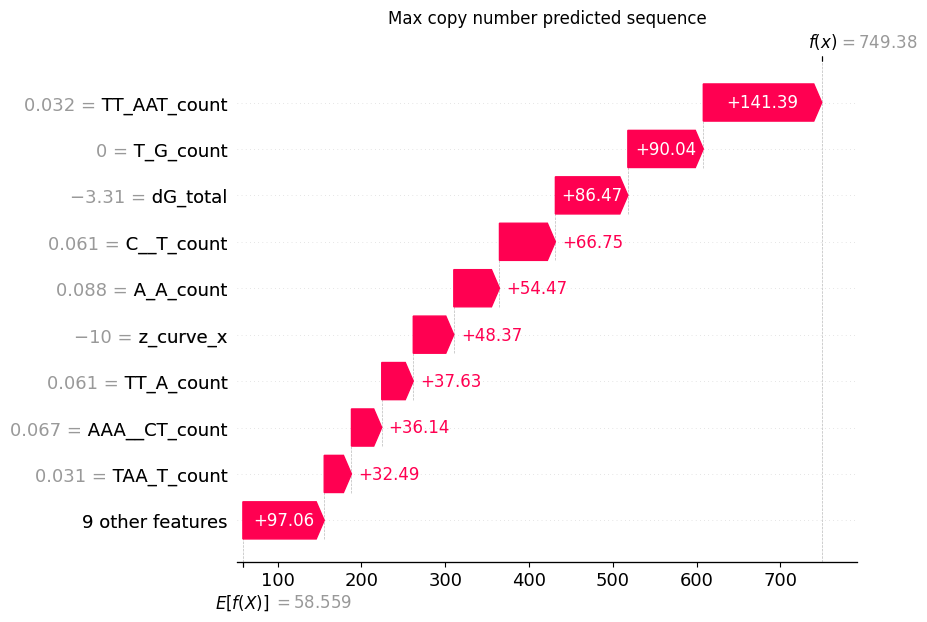

In [8]:
plt.title('Max copy number predicted sequence')
shap.plots.waterfall(shap_values[np.argmax(y_pred)], max_display=10)

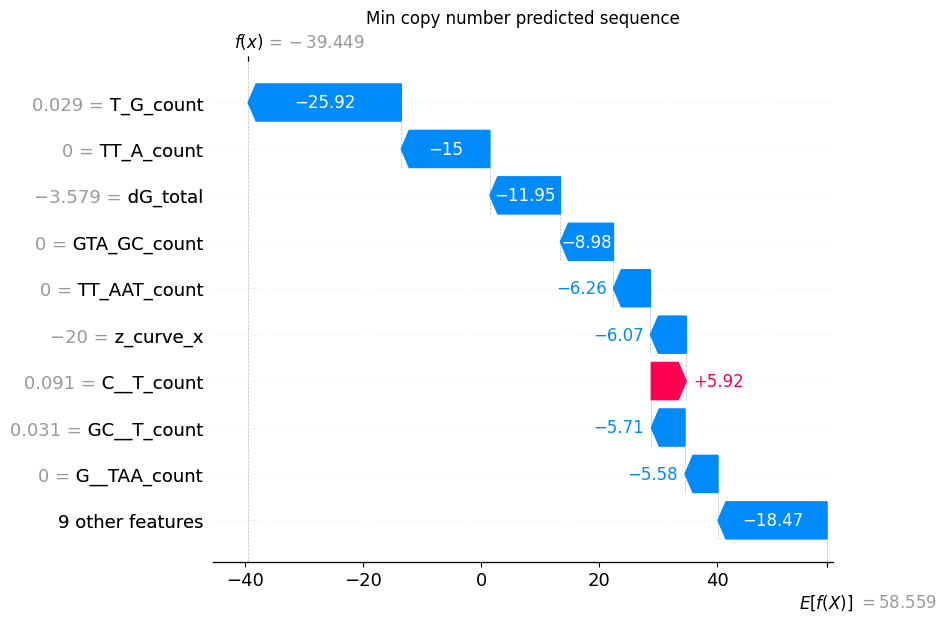

In [9]:
plt.title('Min copy number predicted sequence')
shap.plots.waterfall(shap_values[np.argmin(y_pred)], max_display=10)

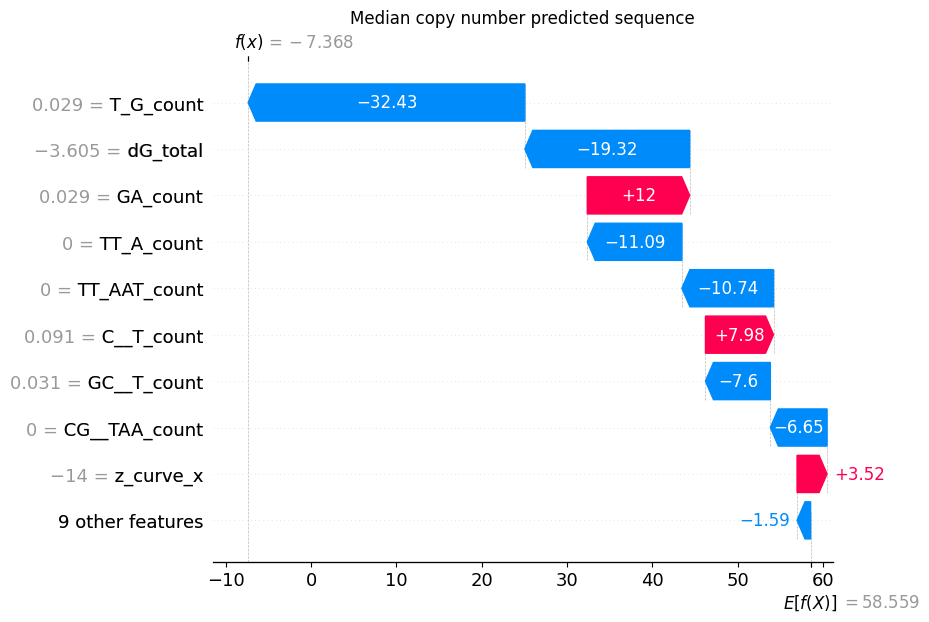

In [10]:
plt.title('Median copy number predicted sequence')
shap.plots.waterfall(shap_values[np.argsort(y_pred)[len(y_pred) // 2]], max_display=10)


Free Energy dG total

In [11]:
TARGET_COLUMN = 'Copy Number' if RNA_TYPE != 'p_fitted' else 'Raw Copy Number'
RNA_X = pd.concat([RNA_X_train_features, RNA_X_val_features, RNA_X_test_features])
RNA_y = pd.concat([RNA_y_train, RNA_y_val, RNA_y_test])
data = pd.concat([RNA_X['dG_total'], RNA_y], axis=1)
copy_number_mean = data[TARGET_COLUMN].mean()


Text(0, 0.5, 'Copy number')

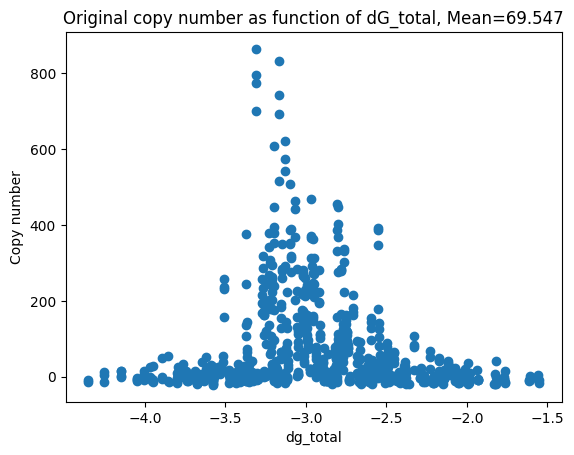

In [12]:
plt.scatter(data['dG_total'], data[TARGET_COLUMN])
plt.title(f'Original copy number as function of dG_total, Mean={copy_number_mean:.3f}')
plt.xlabel('dg_total')
plt.ylabel('Copy number')

In [13]:
## Empirical PV
PCN_TH = 150

above_TH = data.loc[data[TARGET_COLUMN] > PCN_TH]
dG_in_range_above_TH = above_TH[above_TH['dG_total'].between(-3.4, -2.7)]

n_above_TH = above_TH.shape[0]
n_in_range_above_TH = dG_in_range_above_TH.shape[0]
print(f'There are {n_above_TH} sequences above the PCN threshold: {PCN_TH}.')
print(f'There are {n_in_range_above_TH} sequences above the PCN threshold, that are in the dG range of [-3.4,-2.7].')

There are 145 sequences above the PCN threshold: 150.
There are 136 sequences above the PCN threshold, that are in the dG range of [-3.4,-2.7].


In [14]:
num_of_randomizations = 100000
null_counter = 0
for i in range(num_of_randomizations):
    random_sample = data.sample(n_above_TH)
    random_above_TH = random_sample.loc[random_sample[TARGET_COLUMN] > PCN_TH]
    random_dg_in_range_above_TH = random_above_TH[random_above_TH['dG_total'].between(-3.4, -2.7)]
    random_n_in_range_above_TH = random_dg_in_range_above_TH.shape[0]
    if random_n_in_range_above_TH >= n_in_range_above_TH:
        null_counter += 1
enrichment_pv = null_counter / num_of_randomizations
print(f'Empirical Enrichment pv = {enrichment_pv}')

Empirical Enrichment pv = 0.0


Text(-3.1, 800, '33.0% above TH')

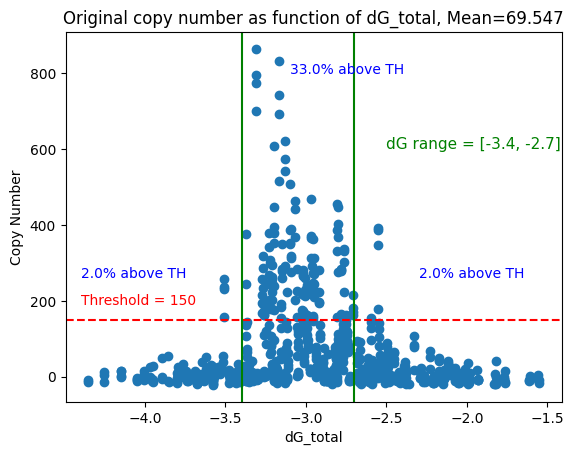

In [15]:
plt.scatter(data['dG_total'], data[TARGET_COLUMN])
plt.title(f'Original copy number as function of dG_total, Mean={copy_number_mean:.3f}')
plt.xlabel('dG_total')
plt.ylabel(TARGET_COLUMN)
plt.axhline(PCN_TH, c='r', linestyle='--')
plt.axvline(-3.4, c='g')
plt.axvline(-2.7, c='g')
plt.text(-4.4, 190, f'Threshold = {PCN_TH}', c='r')
plt.text(-2.5, 600, 'dG range = [-3.4, -2.7]', c='g', fontsize=11)

n_left = data.loc[data['dG_total'] <= -3.4].shape[0]
n_right = data.loc[data['dG_total'] >= -2.7].shape[0]
n_mid = data.shape[0] - n_left - n_right

n_left_above = above_TH.loc[above_TH['dG_total'] <= -3.4].shape[0]
n_right_above = above_TH.loc[above_TH['dG_total'] >= -2.7].shape[0]
n_mid_above = above_TH[above_TH['dG_total'].between(-3.4, -2.7)].shape[0]

plt.text(-4.4, 260, f'{np.round(100 * (n_left_above / n_left))}% above TH', c='b')
plt.text(-2.3, 260, f'{np.round(100 * (n_right_above / n_right))}% above TH', c='b')
plt.text(-3.1, 800, f'{np.round(100 * (n_mid_above / n_mid))}% above TH', c='b')


Text(0, 0.5, 'Copy Number')

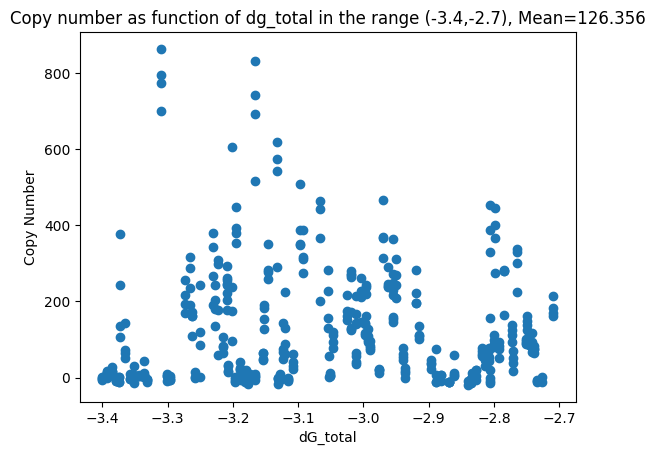

In [16]:
data_dg = data[data['dG_total'].between(-3.4, -2.7)]
plt.scatter(data_dg['dG_total'], data_dg[TARGET_COLUMN])
mean_copy_dg = data_dg[TARGET_COLUMN].mean()
plt.title(f'Copy number as function of dg_total in the range (-3.4,-2.7), Mean={mean_copy_dg:.3f}')
plt.xlabel('dG_total')
plt.ylabel(TARGET_COLUMN)

In [17]:
## Analytical PV
import scipy.stats as stats

#hypergeometric distribution
#M- number of sequences #708
#N- number of sequences in the range (-3.4,-2.7) of dG_total #351
#n- number of sequences with high copy number (above 150) #121
#x- number of sequences with high copy number (above 150) in the range #115
M = data.shape[0]
N = data_dg.shape[0]
data_above_150 = data[data[TARGET_COLUMN] > 150]
n = data_above_150.shape[0]
data_dg_above_150 = data_dg[data_dg[TARGET_COLUMN] > 150]
x = data_dg_above_150.shape[0]
#p-value 0, significant
pv = 1 - stats.hypergeom.cdf(x - 1, M, n, N)
print(f'Analytical enrichment pv = {pv}')

Analytical enrichment pv = 0.0
